In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
def PlotPS_Timeseries(lat, lon, xlims, **kwargs):
    fig, ax = plt.subplots()

    for k, val in kwargs.items():
        ax.plot(val[0],
                val[1].PS.sel(lat=lat, lon=lon) - 100000,
                label=k,
                linestyle=val[2]
                )

    ax.set_ylabel("PS - 1000000 [Pa]")
    ax.set_xlabel("Time [minutes]")
    ax.set_title(f"Lat={lat}, lon={lon}")
    ax.set_xlim(xlims)
    ax.legend()

In [5]:
SCRATCH_NF = "/glade/derecho/scratch/nforcone"

# ne30
SE_NE30_DIR = "/glade/derecho/scratch/nforcone/CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb/run"
SE_NE30_FILE = "CAM_6_4_089_ne30_ne30_mg16_L100_ztop50km_dz500m_pressure_perturb.cam.h0i.0001-01-01-00000.nc"
SE_NE30_PATH = os.path.join(SCRATCH_NF, SE_NE30_DIR, SE_NE30_FILE)
se_ne30 = xr.open_dataset(SE_NE30_PATH)

# ne60
SE_NE60_DIR = "/glade/derecho/scratch/nforcone/CAM_6_4_089_ne60_ne60_mg16_L100_ztop50km_dz500m/run"
SE_NE60_FILE = "CAM_6_4_089_ne60_ne60_mg16_L100_ztop50km_dz500m.cam.h0i.0001-01-01-00000.nc"
SE_NE60_PATH = os.path.join(SCRATCH_NF, SE_NE60_DIR, SE_NE60_FILE)
se_ne60 = xr.open_dataset(SE_NE60_PATH)

# ne60 -- default subcycling
NE60_DEFAULT_SUBCYC_DIR = "/glade/derecho/scratch/nforcone/CAM_6_4_089_ne60_ne60_mg16_L100_ztop50km_dz500m_default_subcycle/run"
NE60_DEFAULT_SUBCYC_FILE = "CAM_6_4_089_ne60_ne60_mg16_L100_ztop50km_dz500m_default_subcycle.cam.h0i.0001-01-01-00000.nc"
NE60_DEFAULT_SUBCYC_PATH = os.path.join(SCRATCH_NF, NE60_DEFAULT_SUBCYC_DIR, NE60_DEFAULT_SUBCYC_FILE)
ne60_default_subcyc = xr.open_dataset(NE60_DEFAULT_SUBCYC_PATH)

# ne120
SE_NE120_DIR = "/glade/derecho/scratch/nforcone/CAM_6_4_089_ne120_ne120_mg16_L100_ztop50km_dz500m/run"
SE_NE120_FILE = "CAM_6_4_089_ne120_ne120_mg16_L100_ztop50km_dz500m.cam.h0i.0001-01-01-00000.nc"
SE_NE120_PATH = os.path.join(SCRATCH_NF, SE_NE120_DIR, SE_NE120_FILE)
se_ne120 = xr.open_dataset(SE_NE120_PATH)

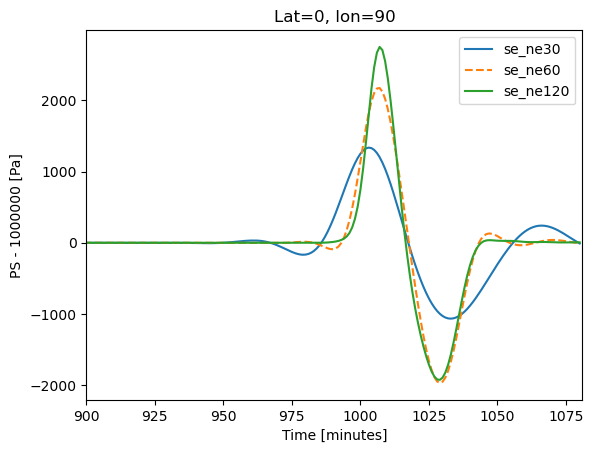

In [6]:
lat = 0
lon = 90
se_times = np.arange(0, 1081, 1)
xlims = (900, 1081)

PlotPS_Timeseries(lat, lon, xlims,
                  se_ne30=(se_times, se_ne30, 'solid'),
                  se_ne60=(se_times, se_ne60, 'dashed'),
                  se_ne120=(se_times, se_ne120, 'solid')
                  )

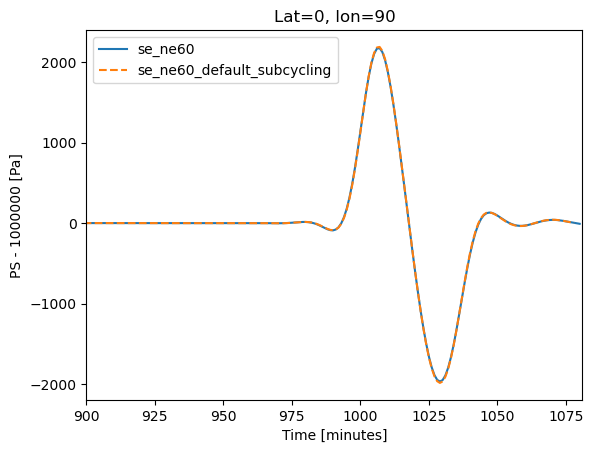

In [10]:
lat = 0
lon = 90
se_times = np.arange(0, 1081, 1)
ne60_default_subcyc_times = np.arange(0, 1079, 1)
xlims = (900, 1081)

PlotPS_Timeseries(lat, lon, xlims,
                  se_ne60=(se_times, se_ne60, 'solid'),
                  se_ne60_default_subcycling=(ne60_default_subcyc_times, ne60_default_subcyc, 'dashed')
                  )

## Notes:
### ne60 no subcycling
- se_rsplit = 1
- se_nsplit = 1
- se_hypervis_subcycle = 1
- ATM_NCPL = 1440
- dt_physics = 60s, dt_dynamics = 60s, dt_remap = 60s, dt_hyperviscosity = 60s

### ne60 default subcycling:
- se_rsplit = 3
- se_nsplit = 2
- se_hypervis_subcycle = 1
- ATM_NCPL = 1440
- dt_physics = 60s, dt_dynamics = 10s, dt_remap = 30s, dt_hyperviscosity = 10s